# Laboratório IAAut — Aprendizagem Não Supervisionada


## Imports e seed

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# NAO MODIFICAR A SEED
# flag = 0 --> random
# flag = 1 --> km++
np.random.seed(555)

## Leitura e normalização dos dados

In [3]:
df_train = pd.read_pickle('Xtrain.pkl')

# todas as poses de todas as sequências numa única matriz: (8374, 66)
X = np.concatenate(df_train['Skeleton_Sequence'].to_numpy())
print(X.shape)

# Normalização dos dados - centrar + escalamento (recomendado e crítico para o PCA)
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

(8374, 66)


## Parte I — k-means

### 1. Implementação

In [4]:
def kminit(X, K, flag):
    # Inicialização - aleatória (flag = 0) ou k-means++ (flag = 1)
    # A inicialização do primeiro centróide é fixa
    N = X.shape[0]
    C = []
    init_centr_idx = np.random.randint(N)
    C.append(X[init_centr_idx])

    if flag == 0:   # random
        idx = np.random.choice(N, K - 1, replace=False)
        while init_centr_idx in idx:   # caso raro --> repetiu o primeiro
            idx = np.random.choice(N, K - 1, replace=False)
        C.extend(X[idx])

    else:           # k-means++
        for _ in range(K - 1):
            C_atual = np.array(C)
            M = np.zeros((N, len(C_atual)))

            # distância ao quadrado de cada pose a cada centroide já escolhido
            for k in range(len(C_atual)):
                M[:, k] = np.sum((X - C_atual[k])**2, axis=1)

            # distância de cada pose ao centroide MAIS PRÓXIMO: (N,)
            d2 = np.min(M, axis=1)

            # probabilidade proporcional a d²
            prob = d2 / np.sum(d2)

            new_idx = np.random.choice(N, p=prob)
            C.append(X[new_idx])

    return np.array(C)

In [5]:
def kmeans_custo(X, C, s):
    # Calcula a função de custo do k-means
    centr_point = C[s]                                   # centroide de cada pose: (N, 66)
    dist_eucl = np.sum((X - centr_point)**2, axis=1)     # distância ao quadrado de cada pose ao seu centroide: (N,)
    total_cost = np.sum(dist_eucl)
    return total_cost

In [6]:
def kmeans(X, K, flag):
    # Aplica o algoritm k-means a matriz de dados X.
    C = kminit(X,K,flag)
    prev_cost = np.inf
    N = X.shape[0]

    while True:
        M = np.zeros((N, K))

        for k in range(K):
            M[:, k] = np.sum((X - C[k])**2, axis=1)     # distância ao quadrado de cada pose ao centroide k: (N,)

        s = np.argmin(M, axis=1)                        # para cada pose, o centroide mais próximo

        total_cost = kmeans_custo(X, C, s)

        # Comparacao dos custos
        if prev_cost - total_cost < 1e-6:
            break
        prev_cost = total_cost

        # Atualizacao dos centroides
        for k in range(K):
            cluster = X[s == k]
            if len(cluster) > 0:
                C[k] = np.mean(cluster, axis=0)

    return C, s

### 2. Selecionar o número de centróides e inicialização

#### R2.a) Inicialização aleatória — mínimo de 10 execuções por K

In [ ]:
Ks = list(range(1, 21))
n_runs = 10

custos_a = np.zeros((len(Ks), n_runs))   # linha = K, coluna = execução
for i, K in enumerate(Ks):
    for r in range(n_runs):
        C, s = kmeans(X_norm, K, 0)
        custos_a[i, r] = kmeans_custo(X_norm, C, s)
    print(f"K = {K} feito")

min_random = np.min(custos_a, axis=1)

K = 1 feito
K = 2 feito
K = 3 feito
K = 4 feito
K = 5 feito
K = 6 feito
K = 7 feito
K = 8 feito
K = 9 feito
K = 10 feito
K = 11 feito
K = 12 feito
K = 13 feito
K = 14 feito
K = 15 feito
K = 16 feito
K = 17 feito
K = 18 feito
K = 19 feito
K = 20 feito


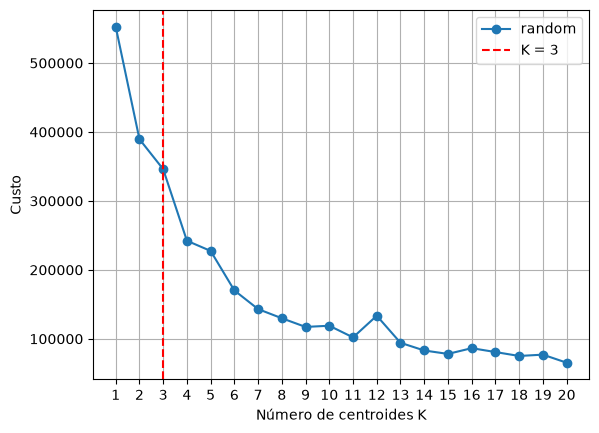

Descidas entre K consecutivos: [163152.20324556  43529.17615879 103773.79255869  14800.36608905
  57277.87859978  27087.98916528  13264.77872346  12572.38836662
  -1710.5344951   16906.18900712 -31435.45896731  39264.06179149
  11158.99534981   4969.06690259  -8338.56680523   5640.79278806
   5672.30987777  -1917.52077582  11679.19524264]
Variação do declive: [ 1.19623027e+05 -6.02446164e+04  8.89734265e+04 -4.24775125e+04
  3.01898894e+04  1.38232104e+04  6.92390357e+02  1.42829229e+04
 -1.86167235e+04  4.83416480e+04 -7.06995208e+04  2.81050664e+04
  6.18992845e+03  1.33076337e+04 -1.39793596e+04 -3.15170897e+01
  7.58983065e+03 -1.35967160e+04]


In [9]:
plt.plot(Ks, min_random, 'o-', label='random')
plt.axvline(x=3, color='red', linestyle='--', label='K = 3')
plt.xlabel('Número de centroides K')
plt.ylabel('Custo')
plt.xticks(Ks)
plt.legend()
plt.grid(True)
plt.savefig('R2a.png', dpi=150)
plt.show()

descidas = -np.diff(min_random)
print("Descidas entre K consecutivos:", descidas)
print("Variação do declive:", -np.diff(descidas))

#### R2.b) Inicialização k-means++ — mínimo de 10 execuções por K

In [1]:
custos_b = np.zeros((len(Ks), n_runs))
for i, K in enumerate(Ks):
    for r in range(n_runs):
        C, s = kmeans(X_norm, K, 1)
        custos_b[i, r] = kmeans_custo(X_norm, C, s)
    print(f"K = {K} feito")

min_pp = np.min(custos_b, axis=1)

NameError: name 'np' is not defined

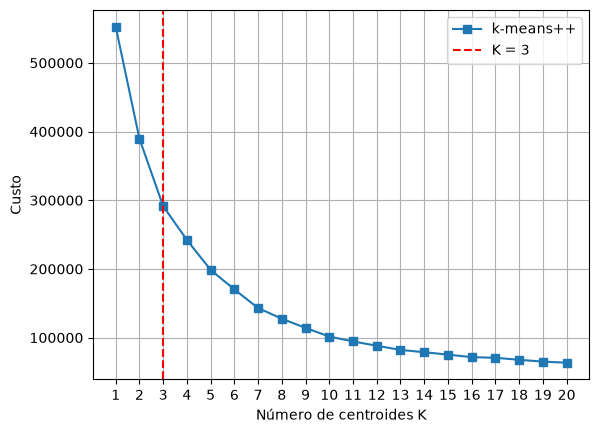

Descidas entre K consecutivos: [163152.20324556  98213.76840042  49089.20031706  43662.06920944
  28416.11992368  27088.31841794  15541.88155771  13398.25601175
  12545.3114046    7126.01237589   6246.78142284   6118.35323529
   3315.58811849   3535.55327122   3671.22341757    910.82287306
   2970.32509982   2638.4839625    1553.64264193]
Variação do declive: [64938.43484514 49124.56808336  5427.13110762 15245.94928576
  1327.80150574 11546.43686022  2143.62554596   852.94460715
  5419.29902871   879.23095305   128.42818755  2802.7651168
  -219.96515274  -135.67014635  2760.40054451 -2059.50222675
   331.84113732  1084.84132057]


In [ ]:
plt.plot(Ks, min_pp, 's-', label='k-means++')
plt.axvline(x=3, color='red', linestyle='--', label='K = 3')
plt.xlabel('Número de centroides K')
plt.ylabel('Custo')
plt.xticks(Ks)
plt.legend()
plt.grid(True)
plt.savefig('R2b.png', dpi=150)
plt.show()

descidas = -np.diff(min_pp)
print("Descidas entre K consecutivos:", descidas)
print("Variação do declive:", -np.diff(descidas))

#### R2.c) 20 execuções por K — média e desvio padrão

In [8]:
n_runs_c = 20

custos_random = np.zeros((len(Ks), n_runs_c))
custos_pp     = np.zeros((len(Ks), n_runs_c))

for i, K in enumerate(Ks):
    for r in range(n_runs_c):
        C, s = kmeans(X_norm, K, 0)                   # random
        custos_random[i, r] = kmeans_custo(X_norm, C, s)

        C, s = kmeans(X_norm, K, 1)                   # k-means++
        custos_pp[i, r] = kmeans_custo(X_norm, C, s)
    print(f"K = {K} feito")

K = 1 feito
K = 2 feito
K = 3 feito
K = 4 feito
K = 5 feito
K = 6 feito
K = 7 feito
K = 8 feito
K = 9 feito
K = 10 feito
K = 11 feito
K = 12 feito
K = 13 feito
K = 14 feito
K = 15 feito
K = 16 feito
K = 17 feito
K = 18 feito
K = 19 feito
K = 20 feito


In [ ]:
# Para refazer o gráfico sem voltar a correr tudo:
# custos_random = np.load('custos_R2c_random.npy')
# custos_pp     = np.load('custos_R2c_pp.npy')

media_random = np.mean(custos_random, axis=1)
std_random   = np.std(custos_random, axis=1)
media_pp     = np.mean(custos_pp, axis=1)
std_pp       = np.std(custos_pp, axis=1)

plt.errorbar(Ks, media_random, yerr=std_random, fmt='o-', capsize=4, label='random')
plt.errorbar(Ks, media_pp, yerr=std_pp, fmt='s-', capsize=4, label='k-means++')
plt.xlabel('Número de centroides K')
plt.ylabel('Custo médio')
plt.xticks(Ks)
plt.legend()
plt.grid(True)
plt.savefig('R2c.png', dpi=150)
plt.show()

for i, K in enumerate(Ks):
    print(f"K={K:2d}  random: {media_random[i]:9.0f} ± {std_random[i]:7.0f}   "
          f"km++: {media_pp[i]:9.0f} ± {std_pp[i]:7.0f}")

NameError: name 'np' is not defined

### 3. Visualização

#### R3.a) Centroides do melhor modelo (K = 3, k-means++, melhor de 10 execuções)
p[a,b] --> Acede ao valor da matriz com estas coordenadas


In [16]:
CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),      # cara
    (11,12),(11,23),(12,24),(23,24),                              # tronco
    (11,13),(13,15),(15,17),(15,19),(15,21),(17,19),              # braço esquerdo
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),              # braço direito
    (23,25),(25,27),(27,29),(27,31),(29,31),                      # perna esquerda
    (24,26),(26,28),(28,30),(28,32),(30,32),                      # perna direita
]

def desenhar_pose(ax, pose, title):
    p = pose.reshape(33, 2)                  # 33 marcadores × (u, v)
    for a, b in CONNECTIONS:
        ax.plot([p[a, 0], p[b, 0]], [p[a, 1], p[b, 1]], 'b-')
    ax.scatter(p[:, 0], p[:, 1], c='red', s=15, zorder=3)
    ax.set_aspect('equal')
    ax.set_title(title)

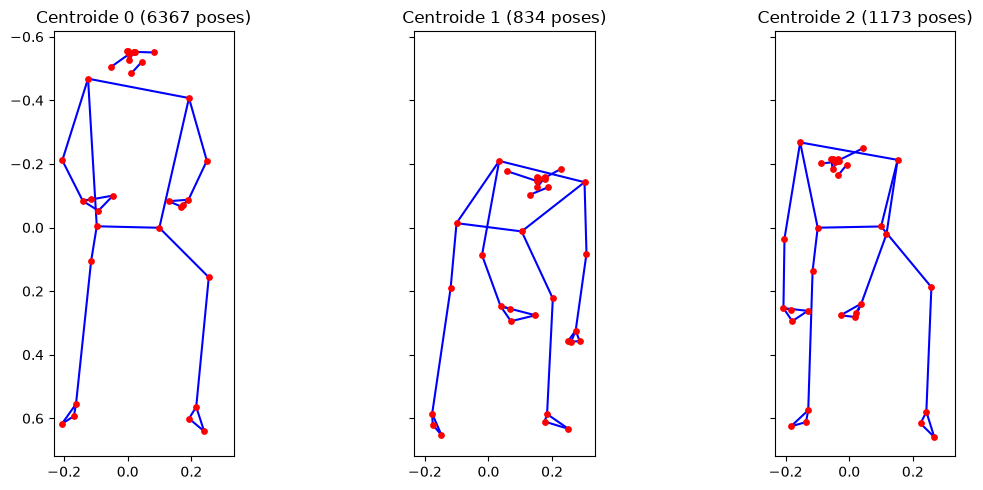

In [17]:
K = 3
low_cost = np.inf

# Procura em 10 iterações o melhor custo
for r in range(n_runs):
    C, s = kmeans(X_norm, K, 1)
    cost = kmeans_custo(X_norm, C, s)
    if cost < low_cost:
        low_cost = cost
        C_best = C.copy()
        s_best = s.copy()

C_original = scaler.inverse_transform(C_best)   # volta às coordenadas (u, v) reais

# eixos partilhados: mesma escala nos K gráficos
fig, axs = plt.subplots(1, K, figsize=(4*K, 5), sharex=True, sharey=True)
for k in range(K):
    n = np.sum(s_best == k)
    desenhar_pose(axs[k], C_original[k], f'Centroide {k} ({n} poses)')

axs[0].invert_yaxis() 
plt.tight_layout()
plt.savefig('R3a_centroides.png', dpi=150)
plt.show()

### PARTE II - PCA e Redução da Dimensionalidade

#### R5.a)


8


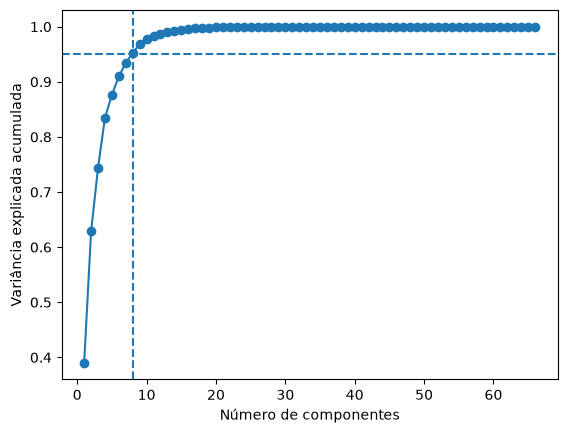

In [19]:
pca = PCA()            # sem n_components
pca.fit(X_norm)        # calculo do pca

var_acum = np.cumsum(pca.explained_variance_ratio_)
n95 = np.argmax(var_acum >= 0.95) + 1
print(n95)

plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')
plt.axhline(0.95, linestyle='--')
plt.axvline(n95, linestyle='--')
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada acumulada')
plt.show()

#### R5.b)


In [22]:
name_markers = [
    'nose', 'left_eye_inner', 'left_eye', 'left_eye_outer',
    'right_eye_inner', 'right_eye', 'right_eye_outer',
    'left_ear', 'right_ear', 'mouth_left', 'mouth_right',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_pinky', 'right_pinky',
    'left_index', 'right_index', 'left_thumb', 'right_thumb',
    'left_hip', 'right_hip', 'left_knee', 'right_knee',
    'left_ankle', 'right_ankle', 'left_heel', 'right_heel',
    'left_foot_index', 'right_foot_index'
]

# Nome de cada uma das 66 features: "13_cotovelo_esq_u", "13_cotovelo_esq_v", ...
name_features = []
for j, name in enumerate(name_markers):   # 33 marcadores
    for c in ('u', 'v'):                      # 2 coordenadas
        name_features.append(f'{j}_{name}_{c}')

# Tabela de pesos: linhas = componentes (PCX), colunas = features originais (0_nose_u , ...)
pesos = pd.DataFrame(pca.components_,
                     index=[f'PC{i+1}' for i in range(pca.n_components_)],
                     columns=name_features)


# Top-k features com maior peso absoluto na componente pc (1, 2, ...)
def top_features(pc, k=10):
    linha = pesos.loc[f'PC{pc}']        # Carrega a linha
    ordem = linha.abs().sort_values(ascending=False).index[:k] # Nomes das k features com maior peso em valor absoluto, por ordem decrescente
    # ordem = lista de 10 features e não valores
    return linha[ordem]         # vai buscar os valores da linha

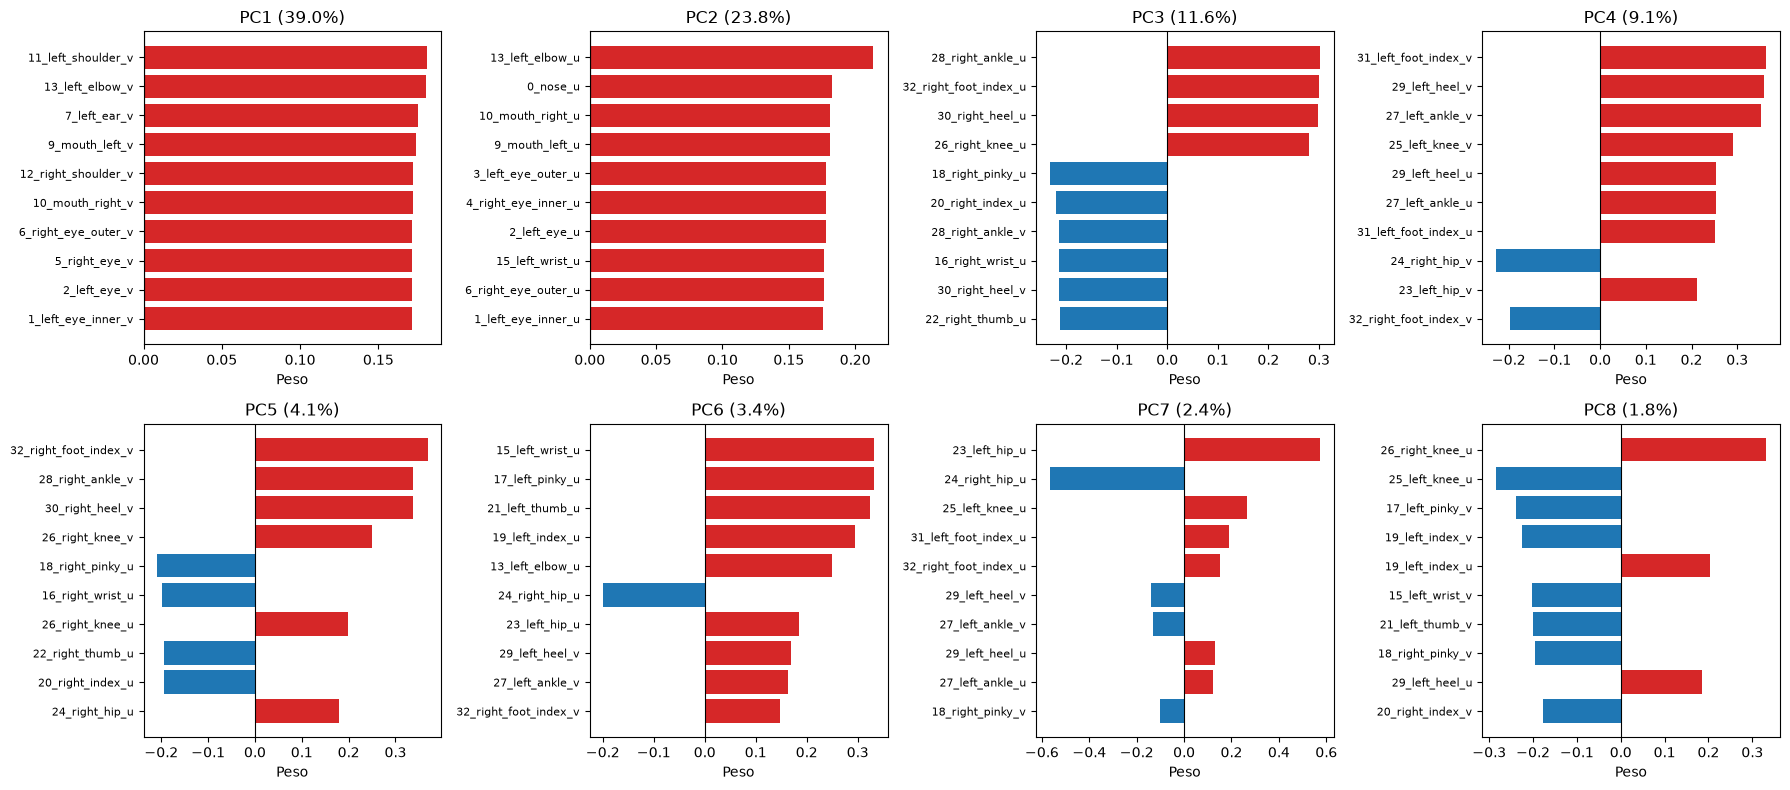

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for pc, ax in zip(range(1, n95 + 1), axes.ravel()):
    top = top_features(pc)[::-1]          # invertido para o maior ficar em cima
    cores = ['tab:red' if p > 0 else 'tab:blue' for p in top]
    ax.barh(top.index, top.values, color=cores)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'PC{pc} ({pca.explained_variance_ratio_[pc-1]:.1%})')
    ax.set_xlabel('Peso')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

#### Projeção de comparação entre os Centroides do R3.a) e as componentes PCx


               PC1   PC2   PC3   PC4   PC5   PC6   PC7   PC8
Centroide 0  -2.21  1.03  0.18  0.06  0.05  0.06 -0.00 -0.13
Centroide 1  12.23  3.23 -0.92 -1.20 -0.24  0.77  0.09  0.42
Centroide 2   3.29 -7.88 -0.31  0.52 -0.12 -0.86 -0.06  0.39

Dispersão entre centróides, por componente:
PC1    7.29
PC2    5.88
PC3    0.55
PC4    0.89
PC5    0.15
PC6    0.82
PC7    0.07
PC8    0.31
dtype: float64


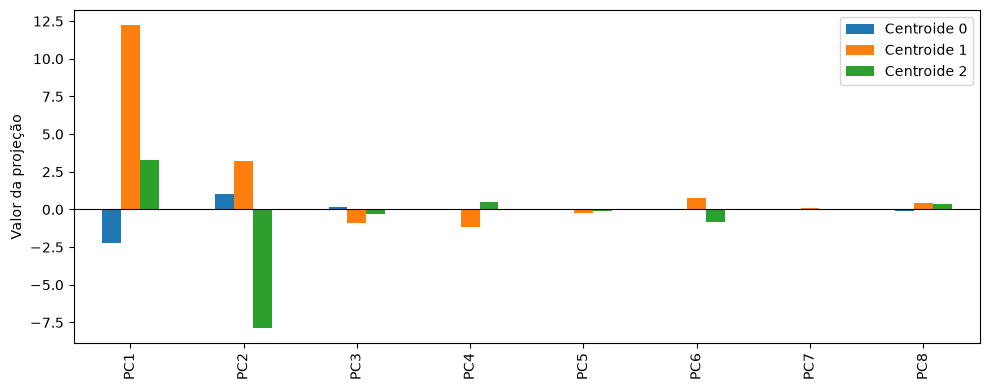

In [21]:
Zc = pd.DataFrame(pca.transform(C_best)[:, :n95],
                  index=[f'Centroide {k}' for k in range(K)],
                  columns=[f'PC{i+1}' for i in range(n95)])

print(Zc.round(2))
print('\nDispersão entre centróides, por componente:')
print(Zc.std().round(2))

Zc.T.plot.bar(figsize=(10, 4))
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Valor da projeção')
plt.tight_layout()
plt.show()